## EV Route Finding System

## Initial Neighbor Finding Code

In [2]:
import pandas as pd
import networkx as nx
from geopy.distance import geodesic
import random
from sklearn.cluster import DBSCAN
import numpy as np
from collections import defaultdict
import math
import pickle

In [ ]:
# Keep only stations with valid coordinates and charger counts
df = pd.read_csv("./ev-charging-station.csv")
df_clean = df.dropna(subset=['Latitude', 'Longitude', 'EV Level2 EVSE Num', 'EV Connector Types']).reset_index(drop=True)
df_clean['EV Level2 EVSE Num'] = df_clean['EV Level2 EVSE Num'].astype(int)

# Parse connector types into sets
df_clean['connector_set'] = df_clean['EV Connector Types'].apply(lambda x: set(map(str.strip, x.split(','))) if isinstance(x, str) else set())

# Clustering
coords = df_clean[['Latitude', 'Longitude']].to_numpy()
kms_per_radian = 6371.0088
epsilon = 20.0 / kms_per_radian  # ~20 km radius
db = DBSCAN(eps=epsilon, min_samples=1, algorithm='ball_tree', metric='haversine').fit(np.radians(coords))
df_clean['cluster'] = db.labels_

# Group by cluster and aggregate
df_clustered = df_clean.groupby('cluster').agg({
    'Latitude': 'mean',
    'Longitude': 'mean',
    'EV Level2 EVSE Num': 'sum',
    'connector_set': lambda sets: set().union(*sets)
}).reset_index(drop=True)

G = nx.Graph()
for idx, row in df_clustered.iterrows():
    G.add_node(
        idx,
        pos=(row['Latitude'], row['Longitude']),
        chargers=row['EV Level2 EVSE Num'],
        connector_types=row['connector_set']
    )

def distance(i, j):
    return geodesic(G.nodes[i]['pos'], G.nodes[j]['pos']).km

def angle_between(lat1, lon1, lat2, lon2):
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    angle = math.degrees(math.atan2(dlon, dlat)) % 360
    return angle

# number of nearest neighbors per node
k = 5

print("Graph node count:", len(G.nodes))
print("Connecting each node to its", k, "nearest neighbors...")

for i in G.nodes:
    distances = []
    lat1, lon1 = G.nodes[i]['pos']

    for j in G.nodes:
        if i == j:
            continue
        lat2, lon2 = G.nodes[j]['pos']
        dist = distance(i, j)
        distances.append((dist, j))

    distances.sort()
    nearest_neighbors = [j for _, j in distances[:k]]

    for j in nearest_neighbors:
        dist = distance(i, j)
        weight = dist / (1 + G.nodes[j]['chargers'])
        G.add_edge(i, j, weight=weight)

    print(f"Node {i} → Neighbors: {nearest_neighbors}")

# Save
with open("graph_data.gpickle", "wb") as f:
    pickle.dump(G, f)

C:\Users\Sarvesh Ram Kumar\AppData\Local\Temp\ipykernel_8252\3988376000.py:2: DtypeWarning: Columns (5,6,26,38,48,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./ev-charging-station.csv")


Graph node count: 2076
Connecting each node to its 5 nearest neighbors...
Node 0 → Neighbors: [743, 101, 131, 1464, 773]
Node 1 → Neighbors: [1723, 2048, 1544, 1995, 845]
Node 2 → Neighbors: [1601, 725, 578, 718, 228]
Node 3 → Neighbors: [470, 1591, 255, 817, 162]
Node 4 → Neighbors: [372, 556, 249, 300, 1042]
Node 5 → Neighbors: [1174, 908, 1254, 359, 191]
Node 6 → Neighbors: [929, 473, 315, 1807, 740]
Node 7 → Neighbors: [1874, 1718, 1034, 1101, 651]
Node 8 → Neighbors: [557, 348, 1877, 1833, 1430]
Node 9 → Neighbors: [1889, 1165, 1360, 595, 625]
Node 10 → Neighbors: [591, 1158, 528, 1751, 700]
Node 11 → Neighbors: [609, 1105, 342, 1663, 1373]
Node 12 → Neighbors: [1484, 1261, 1647, 1059, 1498]
Node 13 → Neighbors: [1576, 1626, 545, 468, 1548]
Node 14 → Neighbors: [798, 1590, 1231, 1800, 1129]
Node 15 → Neighbors: [1102, 523, 282, 1891, 1868]
Node 16 → Neighbors: [1778, 467, 1210, 1224, 1117]
Node 17 → Neighbors: [1554, 1773, 1959, 1479, 881]
Node 18 → Neighbors: [1871, 582, 1084, 19

In [3]:
# Load
with open("graph_data.gpickle", "rb") as f:
    G = pickle.load(f)

## The Environment the Car is going to work upon and Double Q-Learning Algorithm

In [4]:
class EVRouteEnv:
    def __init__(self, graph, start, goal, preferred_connector_type=None):
        self.graph = graph
        self.start = start
        self.goal = goal
        self.state = start
        self.visited = set()
        self.steps = 0
        self.prev_distance_to_goal = float('inf')
        self.distance = 0
        self.visit_counts = defaultdict(int)
        self.preferred_connector_type = preferred_connector_type

    def reset(self):
        self.state = self.start
        self.visited = {self.start}
        self.steps = 0
        self.prev_distance_to_goal = float('inf')
        self.distance = 0
        self.visit_counts.clear()
        return self.state

    def step(self, action):
        if action not in self.graph[self.state]:
            return self.state, -10, False

        self.steps += 1
        prev_pos = self.graph.nodes[self.state]['pos']
        next_pos = self.graph.nodes[action]['pos']
        dist_traveled = geodesic(prev_pos, next_pos).km
        self.distance += dist_traveled

        reward = -dist_traveled

        # Connector-aware charger reward
        node_data = self.graph.nodes[action]
        if node_data.get('chargers', 0) > 0:
            connectors = node_data.get('connector_types', [])
            if self.preferred_connector_type in connectors:
                reward += 10  # Big bonus for preferred connector
            else:
                reward -= 3  # Slight penalty if no preferred connector

        # Reward for progress toward goal
        prev_goal_dist = geodesic(prev_pos, self.graph.nodes[self.goal]['pos']).km
        new_goal_dist = geodesic(next_pos, self.graph.nodes[self.goal]['pos']).km
        reward += 0.5 * (prev_goal_dist - new_goal_dist)

        # Delay penalty
        reward -= min(0.01 * (1.05 ** self.steps), 900)

        # Looping penalty
        if action in self.visited:
            visits = self.visit_counts.get(action, 1)
            reward -= 100 * visits
            self.visit_counts[action] = visits + 1
        else:
            self.visit_counts[action] = 1

        self.state = action
        self.visited.add(action)

        done = self.state == self.goal
        if done:
            reward += 10000

        return self.state, reward, done

    def get_actions(self, state):
        return list(self.graph[state])

class DoubleQLearningAgent:
    def __init__(self, graph, alpha=0.1, gamma=0.9, epsilon=0.2):
        self.Q1 = defaultdict(float)
        self.Q2 = defaultdict(float)
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.graph = graph

    def get_q(self, table, state, action):
        return table.get((state, action), 0.0)

    def choose_action(self, state, actions):
        if random.random() < self.epsilon:
            return random.choice(actions)
        q_values = [(self.Q1[(state, a)] + self.Q2[(state, a)]) / 2 for a in actions]
        max_q = max(q_values)
        return actions[q_values.index(max_q)]

    def learn(self, s, a, r, s_, actions_s_):
        if random.random() < 0.5:
            # Update Q1
            best_action = max(actions_s_, key=lambda x: self.Q1[(s_, x)])
            target = r + self.gamma * self.Q2[(s_, best_action)]
            self.Q1[(s, a)] += self.alpha * (target - self.Q1[(s, a)])
        else:
            # Update Q2
            best_action = max(actions_s_, key=lambda x: self.Q2[(s_, x)])
            target = r + self.gamma * self.Q1[(s_, best_action)]
            self.Q2[(s, a)] += self.alpha * (target - self.Q2[(s, a)])
            
def find_nearest_node(lat, lon):
    return min(G.nodes, key=lambda n: geodesic((lat, lon), G.nodes[n]['pos']).km)

Actual distance: 610
Success threshold: 823.5

RUN: 1
Model distance: 628.3748995744638
ORS distance: 785.0421
Sleep Over

RUN: 2
Model distance: 628.3748995744638
ORS distance: 785.0421
Sleep Over

RUN: 3
Model distance: 610.8735034843345
ORS distance: 762.6631
Sleep Over

RUN: 4
Model distance: 628.3748995744638
ORS distance: 785.0421
Sleep Over

RUN: 5
Model distance: 660.0801507161937
ORS distance: 867.7006000000001
Sleep Over

RUN: 6
Model distance: 610.8735034843345
ORS distance: 762.6631
Sleep Over

RUN: 7
Model distance: 617.3117479982113
ORS distance: 777.3457999999999
Sleep Over

RUN: 8
Model distance: 610.8735034843345
ORS distance: 762.6631
Sleep Over

RUN: 9
Model distance: 659.8253610031284
ORS distance: 862.4845
Sleep Over

RUN: 10
Model distance: 666.8312804586959
ORS distance: 922.6546999999999
Sleep Over

RUN: 11
Model distance: 642.5787546260642
ORS distance: 845.3216000000001
Sleep Over

RUN: 12
Model distance: 610.8735034843345
ORS distance: 762.6631
Sleep Over

RU

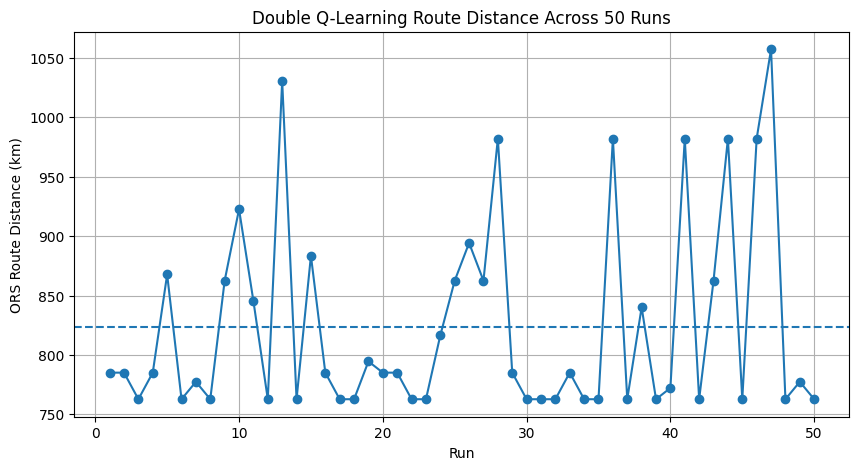

In [ ]:
import random
import numpy as np
from geopy.distance import geodesic
import openrouteservice
import matplotlib.pyplot as plt
import time

ORS_API_KEY = "API-Key" #Replace API-Key Here


# ---------------- TRAIN FUNCTION ----------------
def train_double_q(env, agent, episodes=600, max_steps=10000):

    episode_distances = []
    episode_rewards = []
    episode_steps = []

    for episode in range(episodes):

        state = env.reset()
        done = False
        total_reward = 0
        steps = 0

        while not done and steps < max_steps:

            actions = env.get_actions(state)
            if not actions:
                break

            action = agent.choose_action(state, actions)
            next_state, reward, done = env.step(action)

            next_actions = env.get_actions(next_state)
            agent.learn(state, action, reward, next_state, next_actions)

            state = next_state
            total_reward += reward
            steps += 1

        episode_distances.append(env.distance)
        episode_rewards.append(total_reward)
        episode_steps.append(steps)

    return episode_distances, episode_rewards, episode_steps


# ---------------- TEST FUNCTION ----------------
def test_double_q(env, agent, graph, start_node, goal_node, max_steps=1000):

    agent.epsilon = 0.0

    state = env.reset()
    path = [state]
    step_counter = 0

    coords = []

    lat, lon = graph.nodes[start_node]['pos']
    coords.append((lon, lat))

    done = False

    while not done and step_counter < max_steps:

        actions = env.get_actions(state)
        if not actions:
            break

        action = agent.choose_action(state, actions)
        state, _, done = env.step(action)

        path.append(state)

        lat, lon = graph.nodes[state]['pos']
        coords.append((lon, lat))

        step_counter += 1

    return coords, env.distance


# ---------------- ORS DISTANCE FUNCTION ----------------
def compute_ors_distance(coords):

    client = openrouteservice.Client(key=ORS_API_KEY)

    total_distance = 0
    start_idx = 0

    for end_idx in range(1, len(coords)):

        try:
            res = client.directions(
                coordinates=[coords[start_idx], coords[end_idx]],
                profile='driving-car',
                format='geojson',
                radiuses=[1000, 1000]
            )

            dist = res['features'][0]['properties']['segments'][0]['distance']
            total_distance += dist

            start_idx = end_idx

        except:
            continue

    return total_distance / 1000


# ---------------- MAIN EXPERIMENT LOOP ----------------

runs = 50
success_count = 0
results = []

start_lat, start_lon = 34.05, -118.25
end_lat, end_lon = 37.7749, -122.4194

start_node = find_nearest_node(start_lat, start_lon)
goal_node = find_nearest_node(end_lat, end_lon)

actual_distance = 610
threshold = 1.35 * actual_distance

print("Actual distance:", actual_distance)
print("Success threshold:", threshold)

for run in range(runs):

    print("\nRUN:", run+1)

    env = EVRouteEnv(G, start_node, goal_node, preferred_connector_type='J1772')
    agent = DoubleQLearningAgent(G)

    # Train
    train_double_q(env, agent)

    # Test
    coords, model_distance = test_double_q(env, agent, G, start_node, goal_node)

    # ORS evaluation
    ors_distance = compute_ors_distance(coords)

    print("Model distance:", model_distance)
    print("ORS distance:", ors_distance)
    time.sleep(15)
    print("Sleep Over")

    success = ors_distance <= threshold

    if success:
        success_count += 1

    results.append({
        "run": run+1,
        "model_distance": model_distance,
        "ors_distance": ors_distance,
        "success": success
    })


# ---------------- FINAL ANALYSIS ----------------

success_rate = (success_count / runs) * 100

print("\n==========================")
print("Total Runs:", runs)
print("Successful Routes:", success_count)
print("Success Rate:", success_rate,"%")
print("==========================")

ors_distances = [r["ors_distance"] for r in results]

plt.figure(figsize=(10,5))
plt.plot(range(1,runs+1), ors_distances, marker='o')
plt.axhline(threshold, linestyle='--')
plt.xlabel("Run")
plt.ylabel("ORS Route Distance (km)")
plt.title("Double Q-Learning Route Distance Across 50 Runs")
plt.grid(True)
plt.show()